## **Data Collection and Scope Selection**

### **Import Libraries**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### **Load M5 Raw Datasets**

There are three main source files from Kaggle to for the M5 Project:

- **calendar.csv** — date information including weekday, month, year, SNAP benefit days, and special event details
- **sales_train_validation.csv** — historical daily sales at the individual item (SKU) level, stored in wide format
- **sell_prices.csv** — weekly selling price by store, item, and week

These files are to be merged in later steps to build a unified dataset for analysis and modeling.


In [ ]:
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")

calendar = pd.read_csv(os.path.join(RAW_DIR, "calendar.csv"))
sales    = pd.read_csv(os.path.join(RAW_DIR, "sales_train_validation.csv"))
prices   = pd.read_csv(os.path.join(RAW_DIR, "sell_prices.csv"))

print(f"Calendar shape: {calendar.shape}")
print(f"Sales shape:    {sales.shape}")
print(f"Prices shape:   {prices.shape}\n")

print("Calendar — first 5 rows:")
display(calendar.head())
print("\nSales — first 5 rows:")
display(sales.head())
print("\nPrices — first 5 rows:")
display(prices.head())


Calendar shape: (1969, 14)
Sales shape:    (30490, 1919)
Prices shape:   (6841121, 4)

Calendar — first 5 rows:


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



Sales — first 5 rows:


id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     2     0     0     0     2     0     1     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     2     0     1     0     0     1     1     1     0     2     3   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     0     1     0     0     1     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     0     0     1     2     3     0     2     0     0     2   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   



Prices — first 5 rows:


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


### **Convert Sales Dataset from Wide Format to Long Format**

The sales file stores each day as a separate column (d_1, d_2, ... d_1913) in a wide format. Having this format makes it impossible to merge with calendar dates directly.

The data is reshaped into long format where each row represents:
- one SKU (`item_id`)
- one date key (`d`)
- one daily sales quantity

This data transformation is one of the wrangling steps applied for a typical time-series analysis.


In [3]:
id_cols   = ['id','item_id','dept_id','cat_id','store_id','state_id']
d_cols    = [c for c in sales.columns if c.startswith('d_')]

sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=d_cols,
    var_name='d',
    value_name='sales_qty'
)

print(f"Sales long format shape: {sales_long.shape}")
display(sales_long.head())


Sales long format shape: (58327370, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales_qty
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


### **Merge Sales, Calendar, and Price Data**

The long-format sales data is merged with:
1. **calendar** — to attach actual dates, weekday, month, year, SNAP indicators, and event flags
2. **prices** — to attach weekly selling price by store, item, and week


In [4]:
calendar['date'] = pd.to_datetime(calendar['date'])

df = sales_long.merge(calendar, on='d', how='left')
df = df.merge(prices, on=['store_id','item_id','wm_yr_wk'], how='left')

print(f"Merged dataset shape: {df.shape}")
display(df.head())


Merged dataset shape: (58327370, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales_qty,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


### **Create Event Features Before Aggregation**

The calendar table contains up to two events on the same date:

- `event_name_1` and `event_type_1`
- `event_name_2` and `event_type_2`

Because event fields are categorical, they are converted into simple binary indicators and one count field.

The event features created are:

- **is_event** = 1 if at least one event occurs on that date, else 0
- **is_cultural_event** = 1 if at least one event is cultural
- **is_national_event** = 1 if at least one event is national
- **is_religious_event** = 1 if at least one event is religious
- **is_sport_event** = 1 if at least one event is sporting
- **event_count** = total number of events on that date, which can be 0, 1, or 2


In [5]:
df['is_event'] = (df['event_name_1'].notna() | df['event_name_2'].notna()).astype(int)
df['event_count'] = (df['event_name_1'].notna().astype(int) +
                     df['event_name_2'].notna().astype(int))

df['event_type_1'] = df['event_type_1'].fillna('None')
df['event_type_2'] = df['event_type_2'].fillna('None')

df['is_cultural_event'] = ((df['event_type_1']=='Cultural') | (df['event_type_2']=='Cultural')).astype(int)
df['is_national_event']  = ((df['event_type_1']=='National') | (df['event_type_2']=='National')).astype(int)
df['is_religious_event'] = ((df['event_type_1']=='Religious')| (df['event_type_2']=='Religious')).astype(int)
df['is_sport_event']     = ((df['event_type_1']=='Sporting') | (df['event_type_2']=='Sporting')).astype(int)

display(df[['date','event_name_1','event_type_1','event_name_2','event_type_2',
            'is_event','event_count','is_cultural_event','is_national_event',
            'is_religious_event','is_sport_event']].head(10))


,date,event_name_1,event_type_1,event_name_2,event_type_2,is_event,event_count,is_cultural_event,is_national_event,is_religious_event,is_sport_event
0,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
1,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
2,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
3,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
4,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
5,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
6,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
7,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
8,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0
9,2011-01-29,NaN,None,NaN,None,0,0,0,0,0,0


### **Quick Event Validation**

The table below checks that the event features were built correctly.
All binary flags should contain only 0 and 1.
`event_count` should only contain 0, 1, or 2.


In [6]:
display(df[['is_event','event_count','is_cultural_event',
            'is_national_event','is_religious_event','is_sport_event']].describe())
print("Distinct event_count values:", sorted(df['event_count'].dropna().unique().tolist()))


,is_event,event_count,is_cultural_event,is_national_event,is_religious_event,is_sport_event
count,5.832737e+07,5.832737e+07,5.832737e+07,5.832737e+07,5.832737e+07,5.832737e+07
mean,8.050183e-02,8.259279e-02,1.986409e-02,2.665970e-02,2.770518e-02,8.363826e-03
std,2.720685e-01,2.827598e-01,1.395332e-01,1.610868e-01,1.641268e-01,9.107070e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


Distinct event_count values: [0, 1, 2]


### **Year-on-Year Store Analysis**

Yearly sales are aggregated by store and compared across all years in the dataset to determine which store drives the most demand. 

As the scope for this study, the store with the highest average yearly sales is selected. The analysis below identifies which store it is.


In [7]:
df['year'] = pd.to_datetime(df['date']).dt.year

store_year_sales = df.groupby(['store_id','year'])['sales_qty'].sum().reset_index()
store_sales_yoy  = store_year_sales.pivot(index='store_id', columns='year', values='sales_qty')
store_sales_yoy['avg_yearly_sales'] = store_sales_yoy.mean(axis=1)
store_sales_yoy  = store_sales_yoy.sort_values('avg_yearly_sales', ascending=False)

display(store_sales_yoy)

top_store = store_sales_yoy.index[0]
print("Selected Top Store:", top_store)


year,2011,2012,2013,2014,2015,2016,avg_yearly_sales
store_id,,,,,,,
CA_3,1520827,2099706,2249633,2314556,2276753,726705,1.864697e+06
CA_1,1060793,1406432,1538540,1577931,1606863,507657,1.283036e+06
TX_2,1060623,1460222,1536308,1331780,1364799,460652,1.202397e+06
WI_2,566254,1018731,1401490,1460410,1507628,589499,1.090669e+06
WI_3,1095349,1437700,1201309,1053456,1192198,447770,1.071297e+06
TX_3,850980,1087198,1136181,1235871,1342873,436227,1.014888e+06
CA_2,826083,1032484,1121532,1010213,1208421,486742,9.475792e+05
TX_1,799556,1064111,1105570,1105564,1151251,369240,9.325487e+05
WI_1,540021,725388,1021094,1153819,1274924,433816,8.581770e+05


Selected Top Store: CA_3


### **Why We Focus on the Top-Performing Store**

The analysis above compares yearly sales across all stores in the M5 dataset and identifies the store with the highest average annual sales volume.

In a retail operation like Walmart, the highest-volume store is not just the biggest in terms of numbers — it is also the most complex to operate. A store driving the most sales requires the most inventory, the most replenishment
decisions, the most warehouse space, and the most supply chain coordination. Getting the forecast right for this store has the largest downstream impact on the overall supply chain.

From a demand planning perspective, I choose to focus / prioritize the top store mainly because:

- **It drives the most operational resource consumption.** The store with the highest sales volume is the one that places the largest purchase orders, occupies the most shelf space, and generates the highest replenishment frequency across suppliers and distribution centers. A forecast error here is more costly in absolute terms than the same percentage error at a smaller store.

- **It is where forecasting improvements deliver the most business value.** A 5% reduction in forecast error at the highest-volume store saves significantly more inventory cost and prevents significantly more stockouts than the same improvement at a low-volume store. Focusing resources on the top performer maximizes the return on any forecasting investment.

- **It provides the richest signal for model training.** Higher-volume stores have more consistent daily sales data with fewer zero-sales days, which makes the demand series more stable and forecastable. A model trained on this store will have more data to learn from and is more likely to generalize well.

The code above ranks all stores by average yearly sales and selects the top performer as the scope for this study. Simply, prioritizing to where the business could get the most value out of it.

### **Year-on-Year Category Analysis Within the Selected Store**

Category-level sales are examined within the top store identified to determine which product category drives the most demand.

The category with the highest average yearly sales within the selected store becomes the second dimension of the forecasting scope.


In [8]:
store_df = df[df['store_id'] == top_store].copy()

cat_year_sales = store_df.groupby(['cat_id','year'])['sales_qty'].sum().reset_index()
cat_sales_yoy  = cat_year_sales.pivot(index='cat_id', columns='year', values='sales_qty')
cat_sales_yoy['avg_yearly_sales'] = cat_sales_yoy.mean(axis=1)
cat_sales_yoy  = cat_sales_yoy.sort_values('avg_yearly_sales', ascending=False)

display(cat_sales_yoy)

top_category = cat_sales_yoy.index[0]
print("Selected Top Category:", top_category)


year,2011,2012,2013,2014,2015,2016,avg_yearly_sales
cat_id,,,,,,,
FOODS,1071755,1512872,1493164,1548095,1425613,464291,1.252632e+06
HOUSEHOLD,306335,444210,562414,572306,630907,195271,4.519072e+05
HOBBIES,142737,142624,194055,194155,220233,67143,1.601578e+05


Selected Top Category: FOODS


### **Why We Focus on the FOODS Category**

The FOODS category is selected not only because the data shows it is the largest revenue contributor, but also because it presents the most demanding forecasting challenge in retail — and the one where better forecasts create the most business value.

**FOODS is the primary revenue driver of the business.**
In a large-format grocery retailer like Walmart, majority of transaction volume consistently accounts to food category. Customers visit the store most frequently to replenish perishable grocery items. Thus, FOODS category drives foot traffic, checkout frequency and the top-line sales performance of the entire store. Where FOODS goes, overall store revenue follows.

**FOODS is highly perishable — forecast accuracy directly controls waste and availability.**
Unlike HOBBIES or HOUSEHOLD products, which can sit on the shelf for weeks or months without consequence, food items have strict shelf life constraints. An over-forecast in the FOODS category does not simply result in excess inventory that carries over to the next week — it results in markdown, write-off, or waste. An under-forecast does not just mean a delayed reorder — it means a stockout that cannot be recovered during the sales window, because the customer's need is immediate and sensitive to time.

This creates a very tight operating window for demand planning in food:
- **Too much stock** → spoilage, markdown cost, and working capital tied up in inventory that cannot be sold
- **Too little stock** → stockouts, lost sales, customer dissatisfaction at the shelf, and worse, customer loyalty

Better forecasting directly reduces both of these costs. Every percentage point of MAPE improvement in the FOODS forecast translates into a concrete reduction in either waste or lost revenue — making this category the highest-priority target for any forecasting improvement initiative.

**FOODS demand is driven by more complex signals than other categories.**
Food purchasing behavior responds to SNAP benefit issuance dates, weekend shopping patterns, seasonal events, and promotional pricing. These multiple overlapping demand drivers make food one of the most challenging categories to forecast manually, which is precisely why a data-driven approach using machine learning has the potential to add the most value here compared to traditional rule-of-thumb methods.

The code above ranks all categories within the selected store and confirms FOODS as the top-performing category.


### **Identify Departments Within the Selected Scope**

Within the selected store and category, the department breakdown shows how demand is distributed across sub-categories.

These departments become the individual forecasting units for all succeeding steps.


In [9]:
dept_sales = (
    store_df[store_df['cat_id'] == top_category]
    .groupby('dept_id')['sales_qty']
    .sum()
    .sort_values(ascending=False)
)
print(f"Department sales — {top_store} / {top_category}:")
display(dept_sales)


Department sales — CA_3 / FOODS:


dept_id
FOODS_3    5576362
FOODS_2    1202566
FOODS_1     736862
Name: sales_qty, dtype: int64

### **Departments Within the Selected Scope**

Within CA_3 FOODS, three departments make up the full category. The code above shows the total sales contribution of each department across the full dataset period.

These three departments — FOODS_1, FOODS_2, and FOODS_3 — become the individual forecasting units for all downstream steps. Each will be modeled separately because they might differ in scale, volatility, and demand pattern (to be confirmed later in the EDA step).

FOODS_3 typically carries the largest sales volume, which makes it both the most important department to forecast accurately and the most operationally complex to manage. FOODS_1 and FOODS_2 are relatively smaller in volume but equally important from an availability standpoint — stockouts in any department represent not meeting the desired service level to the customer.

Forecasting at the department level — rather than at the total FOODS category level — preserves the operational granularity needed to drive replenishment decisions for each sub-category independently.


### **Why Forecast at Store-Department Level Instead of SKU Level**

Although the M5 dataset contains sales at the individual item (SKU) level, forecasting at that level creates practical difficulties. Many individual items show sparse demand — long stretches of zero sales, occasional isolated spikes, and no consistent pattern. This makes it hard for any model to learn a reliable signal.

By aggregating to the store-department level, the combined demand of many items smooths out the noise. This makes the underlying trends and weekly seasonality much clearer and more forecastable, while still preserving enough business detail to be operationally useful.

The two charts below illustrate this directly — one shows department-level daily demand, and the other shows two individual items from the same department.


Scope check:
     store_id cat_id  dept_id
8324     CA_3  FOODS  FOODS_3
Unique items: 823


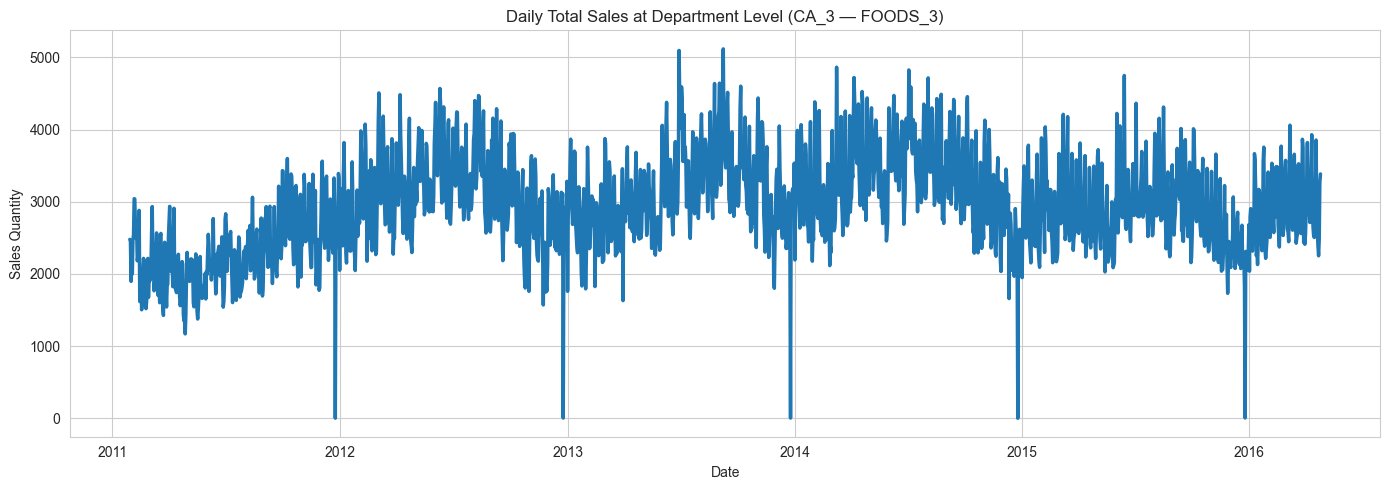

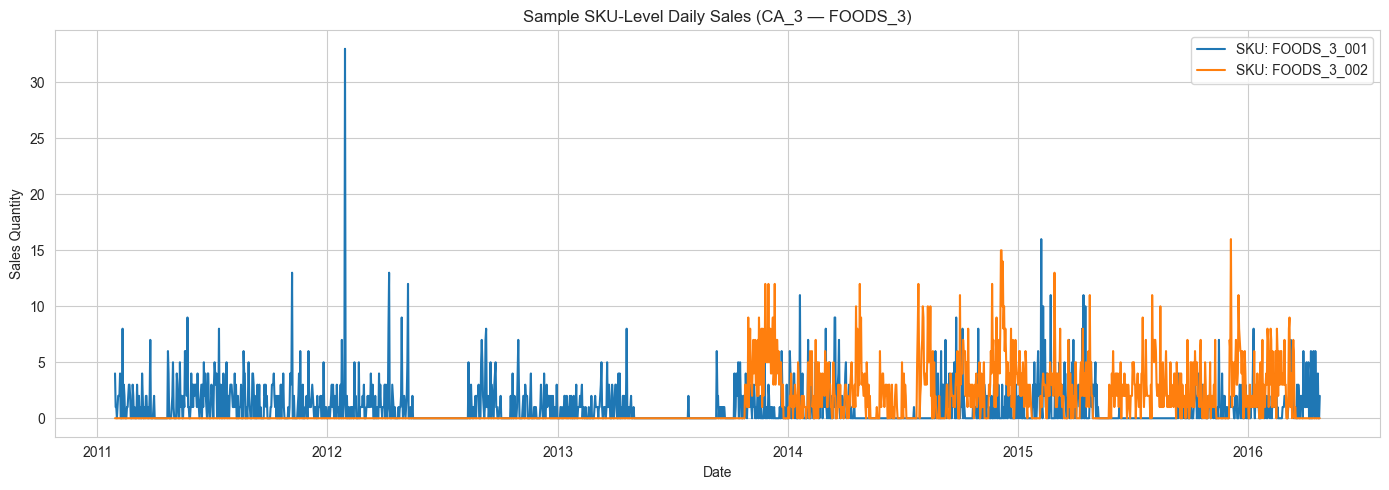

In [10]:
sample_dept = 'FOODS_3'

scope_df = df[
    (df['store_id'] == top_store) &
    (df['cat_id']   == top_category) &
    (df['dept_id']  == sample_dept)
].copy()

print("Scope check:")
print(scope_df[['store_id','cat_id','dept_id']].drop_duplicates())
print("Unique items:", scope_df['item_id'].nunique())

dept_items = scope_df['item_id'].drop_duplicates().tolist()
sku1, sku2 = dept_items[0], dept_items[1]

sku1_daily  = scope_df[scope_df['item_id']==sku1].groupby('date')['sales_qty'].sum().reset_index()
sku2_daily  = scope_df[scope_df['item_id']==sku2].groupby('date')['sales_qty'].sum().reset_index()
dept_daily  = scope_df.groupby('date')['sales_qty'].sum().reset_index()

sns.set_style("whitegrid")

plt.figure(figsize=(14,5))
sns.lineplot(data=dept_daily, x='date', y='sales_qty', linewidth=2.5)
plt.title(f"Daily Total Sales at Department Level ({top_store} — {sample_dept})")
plt.xlabel("Date"); plt.ylabel("Sales Quantity")
plt.tight_layout(); plt.show()

plt.figure(figsize=(14,5))
sns.lineplot(data=sku1_daily, x='date', y='sales_qty', label=f"SKU: {sku1}")
sns.lineplot(data=sku2_daily, x='date', y='sales_qty', label=f"SKU: {sku2}")
plt.title(f"Sample SKU-Level Daily Sales ({top_store} — {sample_dept})")
plt.xlabel("Date"); plt.ylabel("Sales Quantity")
plt.legend(); plt.tight_layout(); plt.show()


### **What the Charts Show**

The department-level chart shows a relatively smooth, consistent demand pattern with clear weekly cycles. The SKU-level charts, by contrast, show far more erratic behavior — many days with zero or near-zero sales and occasional sharp spikes.

This confirms the decision to work at the department level. The department series has enough structure for both traditional statistical models and ML models to learn from. The individual SKU series does not.

For the business to translate the department forecast down to individual item quantities, a top-down disaggregation approach would need to be designed separately (to be discussed on the Critical Thinking and Ethical AI part of the project).


### **Save Outputs for the Next Notebook**

In [ ]:
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

df.to_csv(os.path.join(PROCESSED_DIR, "m5_merged_data.csv"), index=False)

pd.DataFrame({'top_store':[top_store],'top_category':[top_category]}).to_csv(
    os.path.join(PROCESSED_DIR, "scope_selection.csv"), index=False
)

print("Saved: m5_merged_data.csv")
print("Saved: scope_selection.csv")
print(f"Scope: {top_store} / {top_category}")


Saved: m5_merged_data.csv
Saved: scope_selection.csv
Scope: CA_3 / FOODS
